In [ ]:
!pip install pandas tqdm multiprocess

In [ ]:
from google.colab import drive
import tarfile
import os

# Google Drive 마운트
drive.mount('/content/drive')

# tar 파일 경로 (예: Google Drive에 있는 경우)
tar_path = "/content/drive/MyDrive/인공지능 데이터셋 집파일/TL_kor_formatted_04.tar"
extract_path = "/content/unlockedDataset/format04"

# 압축 해제
with tarfile.open(tar_path, "r:*") as tar:
    tar.extractall(path=extract_path)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


데이터 수집 및 전처리

In [ ]:
import json
import os
from tqdm import tqdm
from multiprocess import Pool, cpu_count

# 대상 폴더 내 모든 json 파일 경로 수집
json_file_paths = []
for root, _, files in os.walk(extract_path):
    for file in files:
        if file.endswith('.json'):
            json_file_paths.append(os.path.join(root, file))

# ✅ 여기 추가: 순서를 무작위로 섞기
import random
random.shuffle(json_file_paths)

# 각 json 파일에서 필요한 정보 추출
def parse_json(path):
    try:
        with open(path, 'r', encoding='utf-8') as f:
            data = json.load(f)
            sentence = data['Transcription']['LabelText']
            age = int(data['Speaker']['Age'])
            age_group = data['Speaker']['AgeGroup']
            return {"sentence": sentence, "age": age, "age_group": age_group}
    except:
        return None  # 잘못된 파일 예외 처리

# 병렬 처리 수행
with Pool(cpu_count()) as pool:
    extracted_data = list(tqdm(pool.imap(parse_json, json_file_paths), total=len(json_file_paths)))

# None 제거
extracted_data = [d for d in extracted_data if d is not None]

100%|██████████| 401696/401696 [04:46<00:00, 1402.35it/s]


데이터 균형화

In [ ]:
import pandas as pd
from sklearn.utils import resample

# DataFrame 생성
df = pd.DataFrame(extracted_data)

# 연령대별 개수 확인
print(df['age_group'].value_counts())

# 연령대별 균형 있게 샘플링 (총 50,000개)
target_total = 50000
age_groups = df['age_group'].unique()
samples_per_group = target_total // len(age_groups)

balanced_df = pd.DataFrame()

for group in age_groups:
    group_df = df[df['age_group'] == group]

    # ✅ 여기 추가! group_df 섞기
    group_df = group_df.sample(frac=1).reset_index(drop=True)  # 무작위 셔플

    if len(group_df) >= samples_per_group:
        sampled = resample(group_df, n_samples=samples_per_group)
    else:
        sampled = resample(group_df, n_samples=samples_per_group, replace=True)
    balanced_df = pd.concat([balanced_df, sampled])
    #random_state=42

# 결과 확인
print(balanced_df['age_group'].value_counts())

# 저장 (선택사항)
balanced_df.to_csv("balanced30000data_3.csv", index=False)

age_group
G03    174964
G02    159452
G01     61287
Name: count, dtype: int64
age_group
G02    16666
G03    16666
G01    16666
Name: count, dtype: int64


#그래프로 원래 전체 데이터 분포 확인 추가

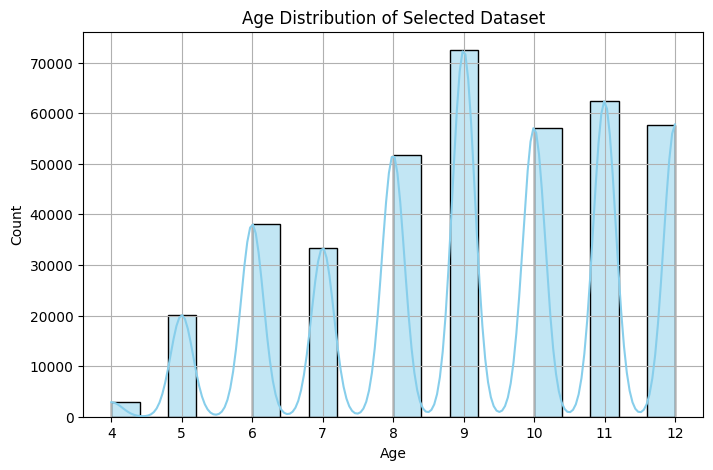

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(df['age'], bins=20, kde=True, color='skyblue')
plt.title('Age Distribution of Selected Dataset')
plt.xlabel('Age')
plt.ylabel('Count')
plt.grid(True)
plt.show()


#그래프로 샘플링한 데이터 분포 그래프 확인

age
4       747
5      5554
6     10230
7      3512
8      5365
9      7686
10     5490
11     5761
12     5653
Name: count, dtype: int64


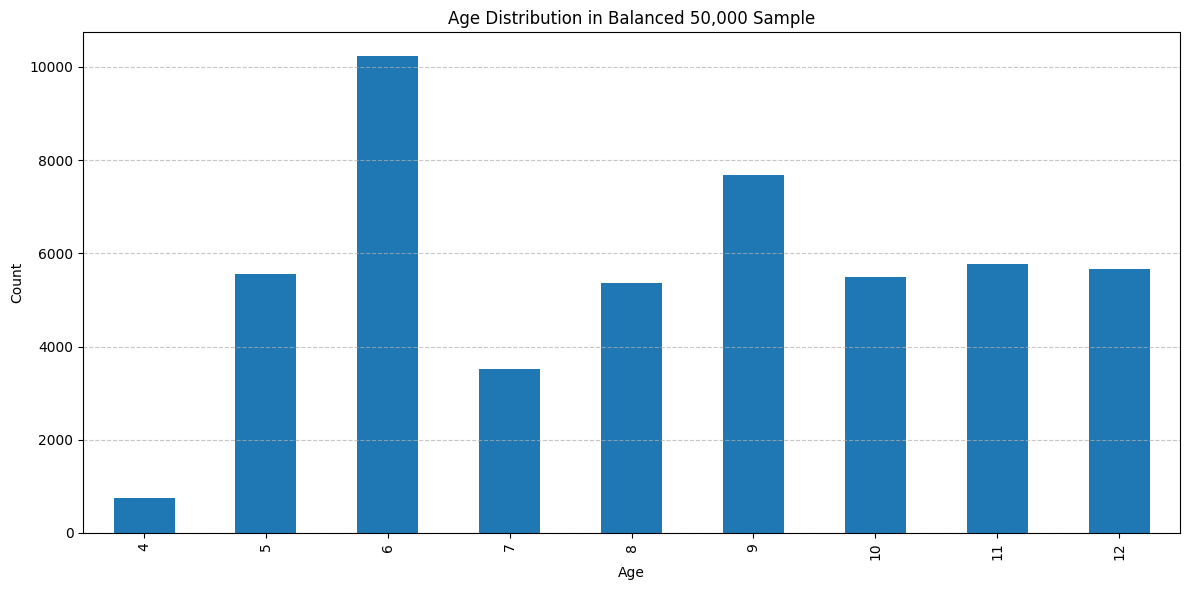

In [ ]:
# 나이별 개수 확인
age_counts = balanced_df['age'].value_counts().sort_index()

# 출력
print(age_counts)

# 시각화 (막대 그래프)
import matplotlib.pyplot as plt

age_counts.plot(kind='bar', figsize=(12, 6))
plt.title('Age Distribution in Balanced 50,000 Sample')
plt.xlabel('Age')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [ ]:
!pip install transformers
!pip install datasets
!pip install sentencepiece
!pip install accelerate
!pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 74.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 61.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 66.6 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [ ]:
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
#from transformers import AutoTokenizer, AutoModel, AdamW

from transformers import AutoTokenizer, AutoModel
from torch.optim import AdamW

from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from tqdm import tqdm

In [ ]:
df = pd.read_csv("balanced30000data_3.csv")

# 학습/검증 데이터 분리
train_df, val_df = train_test_split(df, test_size=0.1, random_state=42)

In [ ]:
MODEL_NAME = "skt/kobert-base-v1"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

In [ ]:
class AgeDataset(Dataset):
    def __init__(self, sentences, ages, tokenizer, max_length=64):
        self.sentences = sentences
        self.ages = ages
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.sentences)

    def __getitem__(self, idx):
        encoded = self.tokenizer(
            self.sentences[idx],
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )

        item = {key: val.squeeze(0) for key, val in encoded.items()}
        item['labels'] = torch.tensor(self.ages[idx], dtype=torch.float)
        return item

In [ ]:
train_dataset = AgeDataset(train_df['sentence'].tolist(), train_df['age'].tolist(), tokenizer)
val_dataset = AgeDataset(val_df['sentence'].tolist(), val_df['age'].tolist(), tokenizer)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=64, num_workers=2)


KoBERT 회귀 모델 학습

In [ ]:
class KoBERTSimpleRegressor(nn.Module):
    def __init__(self, model_name):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.linear = nn.Linear(self.bert.config.hidden_size, 1)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0, :]  # [CLS]
        return self.linear(cls_output).squeeze(-1)  # (batch,)


In [ ]:
def train_epoch(model, dataloader, optimizer, device):
    model.train()
    losses = []

    for batch in tqdm(dataloader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask)
        loss = nn.MSELoss()(outputs, labels)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    return sum(losses) / len(losses)

def eval_epoch(model, dataloader, device):
    model.eval()
    preds, trues = [], []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids, attention_mask)
            preds.extend(outputs.cpu().numpy())
            trues.extend(labels.cpu().numpy())

    mae = mean_absolute_error(trues, preds)
    return mae

#학습실행

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = KoBERTSimpleRegressor(MODEL_NAME).to(device)
optimizer = AdamW(model.parameters(), lr=2e-5)

EPOCHS = 5
for epoch in range(EPOCHS):
    train_loss = train_epoch(model, train_loader, optimizer, device)
    val_mae = eval_epoch(model, val_loader, device)
    print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Val MAE: {val_mae:.2f}")

100%|██████████| 704/704 [07:23<00:00,  1.59it/s]


Epoch 1 | Train Loss: 10.4960 | Val MAE: 1.65


100%|██████████| 704/704 [07:19<00:00,  1.60it/s]


Epoch 2 | Train Loss: 2.9207 | Val MAE: 1.03


100%|██████████| 704/704 [07:18<00:00,  1.60it/s]


Epoch 3 | Train Loss: 1.5808 | Val MAE: 0.88


100%|██████████| 704/704 [07:18<00:00,  1.60it/s]


Epoch 4 | Train Loss: 1.3497 | Val MAE: 0.85


100%|██████████| 704/704 [07:18<00:00,  1.60it/s]


Epoch 5 | Train Loss: 1.2899 | Val MAE: 0.82


In [ ]:
sample_text = "오늘 점심은 엄마, 아빠와 함께 먹고, 내일은 누나랑 먹을것이다."
inputs = tokenizer(sample_text, return_tensors="pt", padding=True, truncation=True).to(device)
with torch.no_grad():
    pred_age = model(inputs['input_ids'], inputs['attention_mask']).item()

print(f"예상 나이: {pred_age:.1f}세")


예상 나이: 11.0세


#테스트 후 괜찮으면 전처리 데이터 로컬 드라이브에 저장

In [ ]:
!cp balanced30000data_3.csv "/content/drive/MyDrive/인지응 데이터셋/balanced50000data_3.csv"

현재 나이 입력 → 예측 → 발달 평가

입력 처리

In [4]:
def input_age_and_speech():
    """나이와 발화 텍스트 입력 처리"""
    while True:
        try:
            current_age = int(input("아동의 현재 나이를 입력하세요 (종료: 0): "))
            if current_age == 0:
                print("프로그램을 종료합니다.")
                return None, None

            sample_text = input("발화 내용 입력: ").strip()
            if not sample_text:
                raise ValueError("발화 내용을 반드시 입력해야 합니다")

            return current_age, sample_text

        except ValueError as e:
            print(f"입력 오류: {e}")

모델 예측 모듈

In [5]:
def predict_age(model, tokenizer, device, text):
    """텍스트 입력 → 나이 예측"""
    inputs = tokenizer(
        text,
        return_tensors="pt",
        padding=True,
        truncation=True
    ).to(device)

    with torch.no_grad():
        pred_age = model(inputs['input_ids'], inputs['attention_mask']).item()
    return pred_age


발달 평가 모듈

In [6]:
def evaluate_development(current, predicted):
    """예측 결과 기반 발달 평가"""
    diff = predicted - current
    advice = ""

    if abs(diff) < 1:
        advice = "발달 수준이 연령에 적합합니다. 정기적인 관찰을 권장합니다."
    elif diff >= 2:
        advice = "언어 발달이 2년 이상 앞서 있습니다. 영재성 검사 고려"
    elif diff >= 1:
        advice = "발달이 다소 빠름. 창의적 활동 기회 확대 필요"
    elif diff <= -2:
        advice = "발달 지연 가능성. 언어 치료사 상담 권장"
    elif diff <= -1:
        advice = "발달 수준 주의 요함. 지속적 모니터링 필요"

    return f"""
    [진단 결과]
    - 실제 나이: {current}세
    - 예측 나이: {predicted:.1f}세
    - 발달 격차: {abs(diff):.1f}년 ({'앞서' if diff >0 else '뒤쳐짐'})

    [전문가 조언]
    {advice}
    """

메인 실행!!!

In [7]:
def main():
    print("\n" + "="*50)
    print("아동 언어 발달 평가 시스템")
    print("="*50)

    while True:
        current_age, text = input_age_and_speech()
        if current_age is None:  # 0 입력 시 종료
            break

        # 예측 수행
        pred_age = predict_age(model, tokenizer, device, text)

        # 결과 출력
        report = evaluate_development(current_age, pred_age)
        print(report)
        print("="*50 + "\n")

# 실행 (모델 학습 완료 후)
if __name__ == "__main__":
    main()



아동 언어 발달 평가 시스템
아동의 현재 나이를 입력하세요 (종료: 0): 4
발화 내용 입력: 안녕하세요


NameError: name 'model' is not defined

제공 예시

==================================================

아동 언어 발달 평가 시스템

==================================================

아동의 현재 나이를 입력하세요 (종료: 0): 5

발화 내용 입력: 나 오늘 친구들이랑 숨바꼭질 했는데 너무 재미있었어요!

    [진단 결과]
    - 실제 나이: 5세
    - 예측 나이: 6.3세
    - 발달 격차: 1.3년 (앞서)
    
    [전문가 조언]
    발달이 다소 빠름. 창의적 활동 기회 확대 필요
==================================================
